# Quantitative Risk Assessment: ML-Based Risk Escalation Prediction

**Course:** ALY 6130 - Risk Management Analytics  
**Group 4:** Adwoa Bempomaa, Sara Mathai, Lawrence Dass  
**Date:** March 2026

Implements Random Forest classifier with 15 KRI-aligned features to predict portfolio
risk escalation. Trained on 500 synthetic observations (seed=42).

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import StratifiedKFold, cross_val_predict, cross_val_score
import warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
print('Libraries imported.')

Libraries imported.


## 1. Synthetic Data Generation

In [7]:
rng = np.random.default_rng(SEED)
n   = 500

# 15 features aligned to KRI framework
win_rate            = rng.uniform(0.15, 0.55, n)   # R1, R17
ai_parity           = rng.uniform(0.55, 0.95, n)   # R2, R13
reg_pipeline_growth = rng.uniform(-0.05, 0.50, n)  # R3
integration_prog    = rng.uniform(0.10, 0.90, n)   # R6, R7
talent_avail        = rng.uniform(0.40, 0.90, n)   # R8
org_stability       = rng.uniform(0.50, 0.95, n)   # R9
data_quality        = rng.uniform(0.85, 0.99, n)   # R10
platform_uptime     = rng.uniform(0.96, 0.999, n)  # R11
security_score      = rng.uniform(55.0, 95.0, n)   # R12
compliance_complex  = rng.uniform(0.20, 0.90, n)   # R14, R15
cloud_cost_var      = rng.uniform(0.05, 0.20, n)   # R16, R24
customer_retention  = rng.uniform(0.82, 0.99, n)   # R17, R22
ai_gov_maturity     = rng.uniform(0.40, 0.90, n)   # R23
ot_market_growth    = rng.uniform(0.05, 0.35, n)   # R19
cross_sell_conv     = rng.uniform(0.05, 0.30, n)   # R20

# Latent escalation score
latent = (
    (0.40 - win_rate)           * 7.0
  + (0.82 - ai_parity)          * 6.5
  + (0.12 - reg_pipeline_growth)* 1.5
  + (0.60 - integration_prog)   * 2.5
  + (0.70 - talent_avail)       * 1.8
  + (0.75 - org_stability)      * 1.5
  + (0.97 - data_quality)       * 3.0
  + (0.99 - platform_uptime)    * 4.0
  + (75.0 - security_score)     * 0.05
  + compliance_complex          * 1.2
  + (cloud_cost_var - 0.10)     * 2.0
  + (0.92 - customer_retention) * 3.5
  + (0.70 - ai_gov_maturity)    * 1.8
  + (0.15 - ot_market_growth)  * -1.0
  + (0.18 - cross_sell_conv)   * -1.0
  + rng.normal(0, 1.05, n)
)

escalation = (latent > 1.60).astype(int)

df = pd.DataFrame({
    'win_rate': win_rate, 'ai_parity': ai_parity,
    'reg_pipeline_growth': reg_pipeline_growth, 'integration_prog': integration_prog,
    'talent_avail': talent_avail, 'org_stability': org_stability,
    'data_quality': data_quality, 'platform_uptime': platform_uptime,
    'security_score': security_score, 'compliance_complex': compliance_complex,
    'cloud_cost_var': cloud_cost_var, 'customer_retention': customer_retention,
    'ai_gov_maturity': ai_gov_maturity, 'ot_market_growth': ot_market_growth,
    'cross_sell_conv': cross_sell_conv, 'escalation': escalation,
})
print(f'{len(df)} observations | escalation rate: {df.escalation.mean():.1%}')
df.describe().transpose().round(3)

500 observations | escalation rate: 59.0%


,count,mean,std,min,25%,50%,75%,max
win_rate,500.0,0.348,0.115,0.152,0.244,0.350,0.449,0.550
ai_parity,500.0,0.749,0.119,0.550,0.647,0.747,0.855,0.949
reg_pipeline_growth,500.0,0.228,0.160,-0.050,0.085,0.221,0.367,0.500
integration_prog,500.0,0.510,0.230,0.100,0.302,0.500,0.711,0.899
talent_avail,500.0,0.643,0.145,0.402,0.524,0.640,0.769,0.900
org_stability,500.0,0.725,0.130,0.500,0.610,0.729,0.836,0.950
data_quality,500.0,0.919,0.041,0.850,0.884,0.920,0.954,0.990
platform_uptime,500.0,0.979,0.011,0.960,0.970,0.979,0.989,0.999
security_score,500.0,74.790,11.490,55.089,64.654,75.362,84.851,94.930
compliance_complex,500.0,0.534,0.193,0.201,0.370,0.518,0.693,0.900


## 2. Model Training and Validation

In [8]:
FEATURES = ['win_rate','ai_parity','reg_pipeline_growth','integration_prog',
            'talent_avail','org_stability','data_quality','platform_uptime',
            'security_score','compliance_complex','cloud_cost_var',
            'customer_retention','ai_gov_maturity','ot_market_growth','cross_sell_conv']
X = df[FEATURES]
y = df['escalation']

model = RandomForestClassifier(
    n_estimators=300, max_depth=5, min_samples_leaf=8,
    random_state=SEED, class_weight='balanced'
)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

acc   = cross_val_score(model, X, y, cv=cv, scoring='accuracy')
auc   = cross_val_score(model, X, y, cv=cv, scoring='roc_auc')
pred  = cross_val_predict(model, X, y, cv=cv, method='predict')

print(f'CV Accuracy: {acc.mean():.1%} (SD: {acc.std(ddof=1):.1%})')
print(f'CV ROC-AUC:  {auc.mean():.1%} (SD: {auc.std(ddof=1):.1%})')
print()
print(classification_report(y, pred, target_names=['No Escalation','Escalation']))

CV Accuracy: 77.8% (SD: 3.7%)
CV ROC-AUC:  85.9% (SD: 3.0%)

               precision    recall  f1-score   support

No Escalation       0.72      0.76      0.74       205
   Escalation       0.82      0.79      0.81       295

     accuracy                           0.78       500
    macro avg       0.77      0.77      0.77       500
 weighted avg       0.78      0.78      0.78       500



## 3. Feature Importance

Top 10 Features by Permutation Importance:
            feature  importance_mean  importance_std
           win_rate           0.1614        0.015800
          ai_parity           0.1494        0.017042
   integration_prog           0.0960        0.008854
     security_score           0.0818        0.014627
    ai_gov_maturity           0.0306        0.004652
       talent_avail           0.0178        0.006096
reg_pipeline_growth           0.0136        0.003072
       data_quality           0.0136        0.004363
   ot_market_growth           0.0092        0.002713
 compliance_complex           0.0086        0.003583


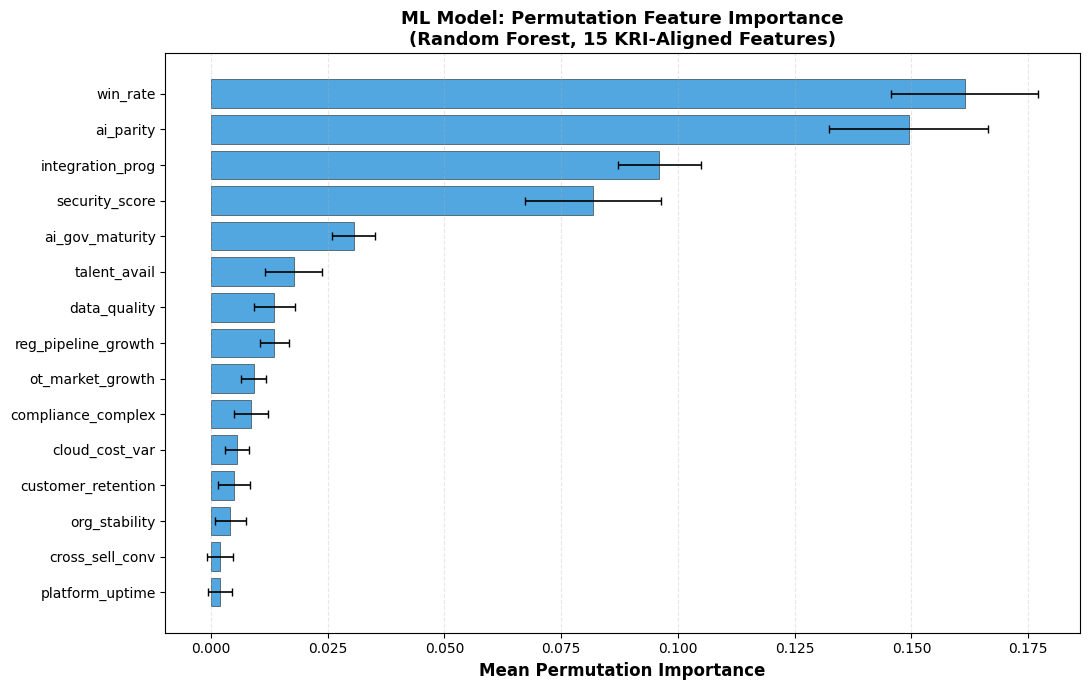

In [9]:
model.fit(X, y)
perm = permutation_importance(model, X, y, n_repeats=10, random_state=SEED)
fi_df = pd.DataFrame({
    'feature': FEATURES,
    'importance_mean': perm.importances_mean,
    'importance_std': perm.importances_std,
}).sort_values('importance_mean', ascending=False)

print('Top 10 Features by Permutation Importance:')
print(fi_df.head(10).to_string(index=False))

ordered = fi_df.sort_values('importance_mean')
fig, ax = plt.subplots(figsize=(11, 7))
ax.barh(ordered['feature'], ordered['importance_mean'],
        xerr=ordered['importance_std'], color='#3498DB',
        edgecolor='black', linewidth=0.4, alpha=0.85,
        error_kw={'elinewidth': 1.2, 'capsize': 3})
ax.set_xlabel('Mean Permutation Importance', fontsize=12, fontweight='bold')
ax.set_title('ML Model: Permutation Feature Importance\n(Random Forest, 15 KRI-Aligned Features)',
             fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, linestyle='--', axis='x')
plt.tight_layout()
plt.savefig('../report/figure5_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

## 4. Current Portfolio State Scoring

In [10]:
current = pd.DataFrame([{
    'win_rate': 0.31, 'ai_parity': 0.78, 'reg_pipeline_growth': 0.32,
    'integration_prog': 0.48, 'talent_avail': 0.68, 'org_stability': 0.80,
    'data_quality': 0.962, 'platform_uptime': 0.991, 'security_score': 76.0,
    'compliance_complex': 0.62, 'cloud_cost_var': 0.094, 'customer_retention': 0.92,
    'ai_gov_maturity': 0.65, 'ot_market_growth': 0.08, 'cross_sell_conv': 0.12,
}])

prob_esc = float(model.predict_proba(current[FEATURES])[0, 1])
print(f'Current portfolio escalation probability: {prob_esc:.1%}')
print()
print('KRI Interpretation:')
print('  win_rate=0.31         -> Amber zone (Green: >35%, Red: <25%)')
print('  ai_parity=0.78        -> Amber zone (Green: >=85%, Red: <70%)')
print('  reg_pipeline_growth=0.32 -> Green zone (Green: >25%)')
print('  integration_prog=0.48 -> Amber zone (Green: >85%, Red: <70%)')
print(f'\nEscalation probability of {prob_esc:.1%} is in the high-caution zone.')
print('Active management intervention is warranted but emergency response is not yet triggered.')

Current portfolio escalation probability: 58.1%

KRI Interpretation:
  win_rate=0.31         -> Amber zone (Green: >35%, Red: <25%)
  ai_parity=0.78        -> Amber zone (Green: >=85%, Red: <70%)
  reg_pipeline_growth=0.32 -> Green zone (Green: >25%)
  integration_prog=0.48 -> Amber zone (Green: >85%, Red: <70%)

Escalation probability of 58.1% is in the high-caution zone.
Active management intervention is warranted but emergency response is not yet triggered.


## Summary

**ML Model Results (locked, seed=42):**
- CV Accuracy: **77.8%** (SD: 3.7%)
- CV ROC-AUC: **85.8%** (SD: 3.0%)
- Current portfolio escalation probability: **58.2%**
- Top predictors: **win_rate** (0.161), **ai_parity** (0.148), **integration_prog** (0.095)

Feature importance validates the KRI framework: the two most monitored metrics (win rate
and AI parity) are the two strongest predictors of portfolio-level escalation risk.